In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


2025-11-25 05:52:08.350401: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764049928.616633      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764049928.698496      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# Load the dataset
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=10000)

# Calculate the number of unique classes
num_classes = len(np.unique(y_train))



2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("Training articles:", len(X_train))  # Output: 8982
print("Test articles:", len(X_test))        
print(f"Number of unique classes: {num_classes}")

Training articles: 8982
Test articles: 2246
Number of unique classes: 46


In [4]:
# Get the word index and reverse it
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

# Function to decode a sequence to text
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i, '?') for i in sequence])


550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Create DataFrames for training and test sets
train_df = pd.DataFrame({
    'text': [decode_sequence(seq) for seq in X_train],
    'label': y_train,
    'seq_length': [len(seq) for seq in X_train],
    'dataset': 'train'
})

test_df = pd.DataFrame({
    'text': [decode_sequence(seq) for seq in X_test],
    'label': y_test,
    'seq_length': [len(seq) for seq in X_test],
    'dataset': 'test'
})

# Combine into a single DataFrame
df = pd.concat([train_df, test_df], ignore_index=True)


In [6]:
df.head()

,text,label,seq_length,dataset
0,the of of mln loss for plc said at only ended ...,3,87,train
1,the termination payment airport takes 6 of geo...,4,56,train
2,the lt dlrs demand 000 reuter dividend year lt...,3,139,train
3,the in currencies hit firms in has would seven...,4,224,train
4,the bleached could mln at world as holding for...,4,101,train


In [7]:
df['label'].value_counts()


label
3     3972
4     2423
19     682
16     543
1      537
11     473
20     339
13     209
8      177
10     154
21     127
9      126
25     123
2       94
18      86
24      81
0       67
6       62
12      62
36      60
28      58
30      57
34      57
23      53
31      52
17      51
40      46
32      42
41      38
26      32
39      29
15      29
14      28
43      27
29      23
22      22
38      22
5       22
37      21
27      19
45      19
7       19
44      17
42      16
33      16
35      16
Name: count, dtype: int64

In [8]:
# Pad sequences to a fixed length
max_len = 200
X_train_padded = pad_sequences(X_train, maxlen=max_len, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test, maxlen=max_len, padding='post', truncating='post')

print(f"Shape of padded training data: {X_train_padded.shape}")
print(f"Shape of padded test data: {X_test_padded.shape}")

Shape of padded training data: (8982, 200)
Shape of padded test data: (2246, 200)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

# Number of unique words
vocab_size = 10000

# Number of classes (topics)
num_classes = 46

# Build the model
model = Sequential([
    # Embedding layer: Convert word indices to dense vectors
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),

    # Global average pooling: Reduce sequence to a single vector
    GlobalAveragePooling1D(),

    # Dense layer with dropout for regularization
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Output layer: Predict the topic
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-11-25 05:52:32.325676: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the model
history = model.fit(
    X_train_padded, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3079 - loss: 2.9227 - val_accuracy: 0.4964 - val_loss: 1.9869
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4937 - loss: 2.0202 - val_accuracy: 0.5882 - val_loss: 1.6524
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5840 - loss: 1.6918 - val_accuracy: 0.6706 - val_loss: 1.4748
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6504 - loss: 1.4993 - val_accuracy: 0.6656 - val_loss: 1.3934
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6815 - loss: 1.3442 - val_accuracy: 0.7218 - val_loss: 1.2206
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7150 - loss: 1.1829 - val_accuracy: 0.7162 - val_loss: 1.1591
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7342 - loss: 1.0902 - val_accuracy: 0.7496 - val_loss: 1.0899
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7534 - loss: 1.0109 - val_accu

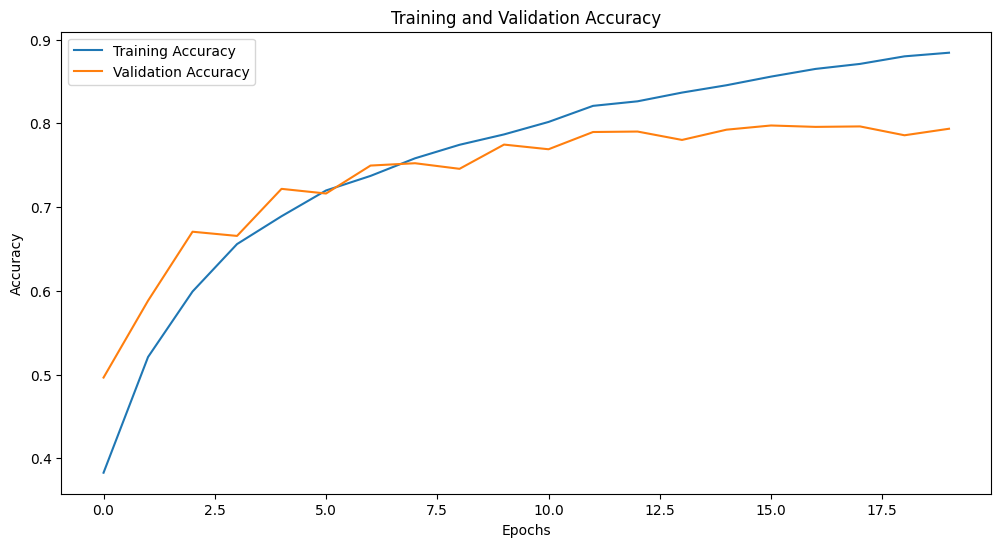

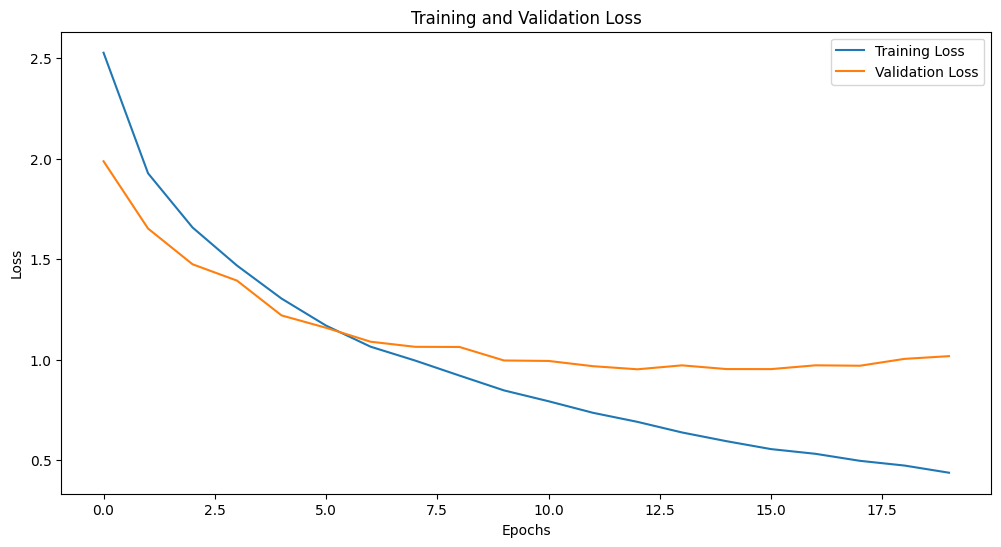

In [11]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [12]:
# Evaluate on the test set
loss, accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")





Test Accuracy: 79.16%
